In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('CarPrice_Assignment.csv')
df = df.drop(columns=['car_ID'])
df = df.select_dtypes(include=np.number)

targets = df['price'].values
features = df.drop(columns='price').values.astype(float)
feature_names = list(df.drop(columns='price').columns)
print('Cars:', features.shape[0], '  Features:', features.shape[1])

Cars: 205   Features: 14


In [3]:
np.random.seed(42)
indices = np.random.permutation(len(targets))

split = int(0.8 * len(targets))
train_idx, test_idx = indices[:split], indices[split:]

X_train, y_train = features[train_idx], targets[train_idx]
X_test,  y_test  = features[test_idx],  targets[test_idx]

print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)

Training set: (164, 14)
Testing set : (41, 14)


In [4]:
def get_normalization_params(features):
    fmean = features.mean(axis=0)
    frange = features.max(axis=0) - features.min(axis=0)
    return fmean, frange

def normalize(features, fmean, frange):
    return (features - fmean) / frange

fmean, frange = get_normalization_params(X_train)
X_train = normalize(X_train, fmean, frange)
X_test  = normalize(X_test,  fmean, frange)

# Bias term: column of ones added as the first column
X_train = np.append(np.ones((len(X_train), 1)), X_train, axis=1)
X_test  = np.append(np.ones((len(X_test), 1)),  X_test,  axis=1)

In [5]:
def predict(features, weights):
    return np.dot(features, weights)

def cost_function(features, targets, weights):
    N = len(targets)
    predictions = predict(features, weights)
    sq_error = (predictions - targets)**2
    return 1.0/(2*N) * sq_error.sum()

def update_weights(features, targets, weights, lr):
    predictions = predict(features, weights)
    gradient = np.dot(-features.T, targets - predictions)
    gradient /= len(features)
    weights -= lr * gradient
    return weights

def train(features, targets, weights, lr, iters):
    cost_history = []
    for i in range(iters):
        weights = update_weights(features, targets, weights, lr)
        cost = cost_function(features, targets, weights)
        cost_history.append(cost)
        if i % 500 == 0:
            print("iter={:d}    cost={:.2f}".format(i, cost))
    return weights, cost_history

In [6]:
weights = np.zeros(X_train.shape[1])
weights, cost_history = train(X_train, y_train, weights, 0.1, 5000)

iter=0    cost=97088517.87
iter=500    cost=5683368.11
iter=1000    cost=4879151.21
iter=1500    cost=4598448.98
iter=2000    cost=4480928.89
iter=2500    cost=4423614.44
iter=3000    cost=4390843.00
iter=3500    cost=4369128.43
iter=4000    cost=4353039.83
iter=4500    cost=4340230.46


In [7]:
train_pred = predict(X_train, weights)
test_pred  = predict(X_test,  weights)

results = pd.DataFrame({'Actual price': y_test,
                        'Predicted price': test_pred.round(0),
                        'Error': (y_test - test_pred).round(0)})
results.head(10)

,Actual price,Predicted price,Error
0,15690.0,21969.0,-6279.0
1,15040.0,19027.0,-3987.0
2,11549.0,13804.0,-2255.0
3,18420.0,18379.0,41.0
4,10795.0,12483.0,-1688.0
5,7395.0,5740.0,1655.0
6,11900.0,14176.0,-2276.0
7,5195.0,5343.0,-148.0
8,19045.0,20787.0,-1742.0
9,9989.0,13342.0,-3353.0


In [8]:
def r2_score(y, p):
    return 1 - np.sum((y - p)**2) / np.sum((y - y.mean())**2)

def rmse(y, p):
    return np.sqrt(np.mean((y - p)**2))

def mae(y, p):
    return np.mean(np.abs(y - p))

metrics = pd.DataFrame({
    'Training': [cost_function(X_train, y_train, weights), r2_score(y_train, train_pred), rmse(y_train, train_pred), mae(y_train, train_pred)],
    'Testing':  [cost_function(X_test,  y_test,  weights), r2_score(y_test,  test_pred),  rmse(y_test,  test_pred),  mae(y_test,  test_pred)]
}, index=['Cost', 'R2', 'RMSE', 'MAE'])
metrics.round(3)

,Training,Testing
Cost,4329607.159,7586965.721
R2,0.855,0.804
RMSE,2942.654,3895.373
MAE,2095.983,2889.993


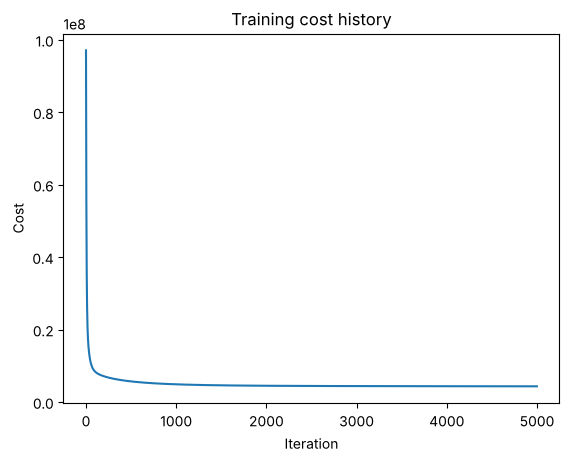

In [9]:
plt.plot(cost_history)
plt.xlabel('Iteration'); plt.ylabel('Cost')
plt.title('Training cost history')
plt.show()

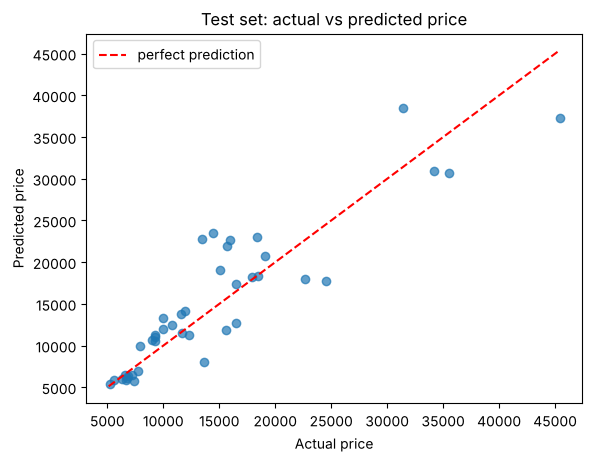

In [10]:
plt.scatter(y_test, test_pred, alpha=0.7)
lim = [targets.min(), targets.max()]
plt.plot(lim, lim, 'r--', label='perfect prediction')
plt.xlabel('Actual price'); plt.ylabel('Predicted price')
plt.title('Test set: actual vs predicted price')
plt.legend()
plt.show()